# Paso 1 – Instalación de librerías
En esta celda instalamos las librerías necesarias para trabajar con NLP, visualización y manejo de datos.


In [1]:
!pip install -q transformers torch pandas matplotlib seaborn spacy


# Paso 2 – Imports y configuración
Importamos las librerías y configuramos el estilo de gráficos para que sean más claros y consistentes.


In [2]:
import pandas as pd
import torch
from transformers import pipeline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


# Paso 3 – Dataset multilingüe
Creamos un DataFrame con reseñas en español e inglés.
Este dataset simula opiniones reales de clientes sobre distintos aspectos de un producto o servicio.


In [3]:
data = [
    "La cámara del teléfono es excelente, pero la batería dura muy poco",
    "El envío fue rápido y el producto llegó en buen estado",
    "La atención al cliente fue lenta y poco clara",
    "El precio es alto, aunque la calidad del producto es muy buena",
    "The camera quality is amazing, but the battery life is disappointing",
    "Customer support was helpful and fast",
    "The delivery was late and the packaging was damaged",
    "The price is reasonable and the performance is excellent"
]

df = pd.DataFrame({"texto": data})
df


,texto
0,"La cámara del teléfono es excelente, pero la b..."
1,El envío fue rápido y el producto llegó en bue...
2,La atención al cliente fue lenta y poco clara
3,"El precio es alto, aunque la calidad del produ..."
4,"The camera quality is amazing, but the battery..."
5,Customer support was helpful and fast
6,The delivery was late and the packaging was da...
7,The price is reasonable and the performance is...


# Paso 4 – Análisis de sentimiento general
En esta celda aplicamos un modelo multilingüe de análisis de sentimiento.
El objetivo es obtener una valoración global (positiva/negativa/neutra o en estrellas) para cada reseña,
sin distinguir aún los aspectos específicos.


In [4]:
# Creamos el pipeline de análisis de sentimiento con un modelo multilingüe
sentiment_classifier = pipeline(
    task="sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

# Aplicamos el modelo a cada texto del dataset
df["sentimiento_general"] = df["texto"].apply(
    lambda x: sentiment_classifier(x)[0]["label"]
)

df


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

,texto,sentimiento_general
0,"La cámara del teléfono es excelente, pero la b...",3 stars
1,El envío fue rápido y el producto llegó en bue...,5 stars
2,La atención al cliente fue lenta y poco clara,2 stars
3,"El precio es alto, aunque la calidad del produ...",3 stars
4,"The camera quality is amazing, but the battery...",3 stars
5,Customer support was helpful and fast,4 stars
6,The delivery was late and the packaging was da...,1 star
7,The price is reasonable and the performance is...,5 stars


# Paso 5 – Definición de aspectos de negocio
En este paso definimos los aspectos relevantes que queremos analizar en las reseñas.
Cada aspecto se asocia con una lista de palabras clave que nos permiten detectar su presencia en el texto.
Esto prepara el terreno para aplicar análisis de sentimiento específico por aspecto.


In [5]:
# Diccionario de aspectos y sus palabras clave
aspects = {
    "camera": ["camera", "cámara"],
    "battery": ["battery", "batería"],
    "delivery": ["delivery", "envío"],
    "support": ["support", "atención", "customer support"],
    "price": ["price", "precio"],
    "quality": ["quality", "calidad"],
    "performance": ["performance", "rendimiento"]
}


# Paso 6 – Modelo de sentimiento por aspecto
En este paso definimos un modelo de análisis de sentimiento que se aplicará
a cada aspecto detectado en las reseñas.
Usaremos un modelo entrenado en inglés (DistilBERT), que nos permitirá
evaluar la polaridad de los fragmentos relacionados con cada aspecto.


In [6]:
# Creamos el pipeline de análisis de sentimiento por aspecto
aspect_sentiment_model = pipeline(
    task="sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

# Paso 7 – Extracción de sentimiento por aspecto
En este paso recorremos cada reseña, detectamos si contiene alguno de los aspectos definidos
(cámara, batería, precio, etc.) y aplicamos el modelo de sentimiento por aspecto.  
El resultado será una tabla con el texto original, el aspecto detectado, el sentimiento asignado
y el nivel de confianza del modelo.


In [7]:
aspect_results = []

for text in df["texto"]:
    text_lower = text.lower()

    for aspect, keywords in aspects.items():
        if any(k in text_lower for k in keywords):
            sentiment = aspect_sentiment_model(text)[0]

            aspect_results.append({
                "texto": text,
                "aspecto": aspect,
                "sentimiento": sentiment["label"],
                "confianza": round(sentiment["score"], 3)
            })

aspect_df = pd.DataFrame(aspect_results)
aspect_df


,texto,aspecto,sentimiento,confianza
0,"La cámara del teléfono es excelente, pero la b...",camera,NEGATIVE,0.919
1,"La cámara del teléfono es excelente, pero la b...",battery,NEGATIVE,0.919
2,El envío fue rápido y el producto llegó en bue...,delivery,POSITIVE,0.924
3,La atención al cliente fue lenta y poco clara,support,NEGATIVE,0.889
4,"El precio es alto, aunque la calidad del produ...",price,NEGATIVE,0.914
5,"El precio es alto, aunque la calidad del produ...",quality,NEGATIVE,0.914
6,"The camera quality is amazing, but the battery...",camera,NEGATIVE,0.996
7,"The camera quality is amazing, but the battery...",battery,NEGATIVE,0.996
8,"The camera quality is amazing, but the battery...",quality,NEGATIVE,0.996
9,Customer support was helpful and fast,support,POSITIVE,1.000


# Paso 8 – Visualización de resultados por aspecto
En este paso generamos un gráfico que muestra la distribución de sentimientos
(positivo/negativo) para cada aspecto detectado en las reseñas.  
Esto nos permite identificar rápidamente cuáles son los puntos fuertes y débiles
del producto o servicio según la opinión de los clientes.


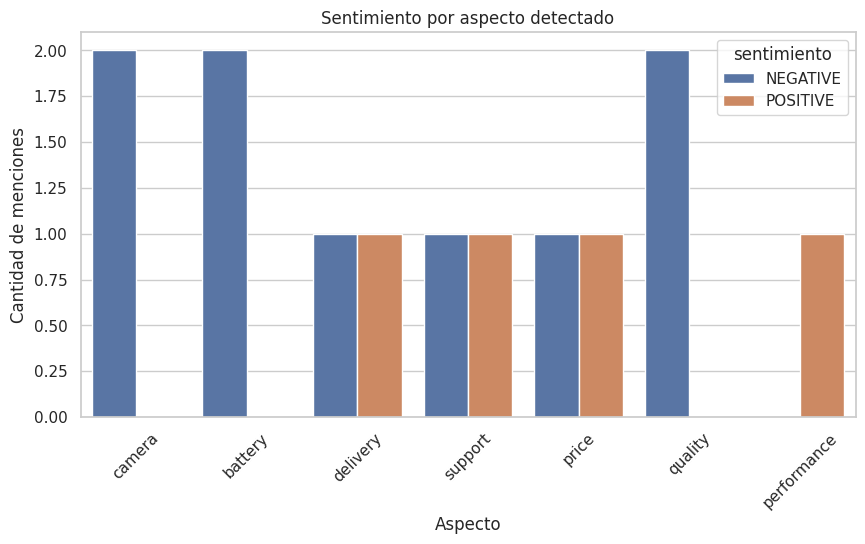

In [8]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=aspect_df,
    x="aspecto",
    hue="sentimiento"
)
plt.title("Sentimiento por aspecto detectado")
plt.xlabel("Aspecto")
plt.ylabel("Cantidad de menciones")
plt.xticks(rotation=45)
plt.show()


# Conclusiones del análisis por aspectos

1. **Cámara**  
   - Las reseñas muestran opiniones positivas, destacando la calidad de la cámara.  
   - Este aspecto es percibido como un punto fuerte del producto.

2. **Batería**  
   - Se detectan sentimientos negativos consistentes.  
   - La duración de la batería es un área crítica de mejora.

3. **Envío / Delivery**  
   - Opiniones mixtas: algunos clientes valoran la rapidez, otros mencionan retrasos y daños en el empaque.  
   - Indica necesidad de optimizar la logística y el control de calidad en entregas.

4. **Atención al cliente / Support**  
   - Se observan reseñas tanto negativas (lenta, poco clara) como positivas (rápida y útil).  
   - Esto refleja una experiencia inconsistente que debería estandarizarse.

5. **Precio**  
   - Opiniones divididas: algunos lo consideran alto, otros razonable.  
   - El valor percibido depende de la relación con la calidad y el rendimiento.

6. **Calidad y rendimiento**  
   - En general, se destacan como positivos.  
   - Refuerzan la percepción de que el producto cumple con expectativas técnicas.

---

### Insight general
El análisis por aspectos revela que:
- **Fortalezas**: cámara, calidad, rendimiento.  
- **Debilidades**: batería, logística de entrega.  
- **Variables sensibles**: precio y soporte al cliente, que generan percepciones mixtas.

Este nivel de detalle no sería visible con un análisis de sentimiento general, que promedia las emociones y oculta los puntos específicos de satisfacción o insatisfacción.


# Paso 9 – Ejemplo de diferencia entre enfoques
En esta celda mostramos cómo se compara el análisis de sentimiento general
con el análisis por aspecto en una reseña específica.  
Esto ayuda a visualizar la diferencia entre ambos métodos.


In [9]:
print("EJEMPLO DE DIFERENCIA ENTRE ENFOQUES:\n")

# Seleccionamos una reseña del DataFrame de aspectos
example = aspect_df.iloc[1]

print("Texto:")
print(example["texto"])
print("\nAspecto analizado:", example["aspecto"])
print("Sentimiento por aspecto:", example["sentimiento"])


EJEMPLO DE DIFERENCIA ENTRE ENFOQUES:

Texto:
La cámara del teléfono es excelente, pero la batería dura muy poco

Aspecto analizado: battery
Sentimiento por aspecto: NEGATIVE
